In [ ]:
%pip install puremacro


# Aggregate shocks in a heterogeneous economy

Add aggregate TFP shocks to the Aiyagari economy and the *entire wealth
distribution* becomes a state variable. Krusell & Smith (1998) showed that
households can forecast the future with a single moment — mean capital — and be
almost exactly right ("approximate aggregation"). We solve that fixed point,
then show a perfect-foresight transition and the representative-agent benchmark.

## The method in math

Add aggregate TFP $Z$ to Aiyagari and the household value function gains *two*
aggregate arguments — the level of capital $K$ and the shock $Z$:
$$ V(a,z;\,K,Z) = \max_{a'\ge 0}\; u(c) + \beta\,\mathbb{E}\!\left[V(a',z';\,K',Z')\mid z,Z\right],
\qquad c = w\,z + (1+r)\,a - a'. $$
Prices come from the aggregate Cobb-Douglas technology, now scaled by $Z$:
$$ r = \alpha\,Z\,(K/L)^{\alpha-1} - \delta, \qquad w = (1-\alpha)\,Z\,(K/L)^{\alpha}. $$
The *true* aggregate state is the entire wealth distribution $\mu$, because tomorrow's
$K'=\int a'\,d\mu$ depends on every household's saving. Krusell & Smith's insight is to
replace $\mu$ with a single moment and a **log-linear forecast rule**, one per aggregate state:
$$ \log K' = b_0(Z) + b_1(Z)\,\log K. $$
Households solve their problem taking this rule as given; in equilibrium the rule must
reproduce the $K'$ the simulated distribution actually delivers. **Approximate aggregation**
is the empirical finding that the rule fits with $R^2\approx 0.999$ — a single moment (mean
$K$) is a near-sufficient statistic for the whole distribution.

**Intuition.** Carrying $\mu$ as a state is hopeless: it is an infinite-dimensional object,
so the value function would live on a space no computer can grid. Why does *one* moment
suffice? Because the saving policy $a'(a,z)$ is very nearly **linear in wealth** over the
region where most mass sits, so the economy's aggregate saving depends almost entirely on
*mean* capital, not on how that capital is spread across households. Redistributing wealth
between two agents on the linear part of the policy barely moves the total they save — so the
higher moments of $\mu$ are nearly irrelevant for forecasting $K'$. The two extra pieces below
stress-test this: the **transition path** (an MIT shock — a one-off, perfectly-anticipated
deviation from steady state) shows how prices and capital travel *between* steady states, and
the **representative-agent** model strips out heterogeneity entirely as the limiting benchmark.

In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

_cwd = Path.cwd()
sys.path.insert(0, str(_cwd if (_cwd / "_nbstyle.py").exists() else _cwd / "notebooks"))
import _nbstyle
_nbstyle.apply_style()

from puremacro.vfi import (
    krusell_smith, neoclassical_growth, aiyagari_steady_state,
    transition_path, VFIProblem, markov_stationary,
)

## 1. Krusell–Smith: solve the forecast-rule fixed point
We iterate: solve the household (mean K folded into the exogenous state) →
simulate the wealth distribution along a drawn aggregate path → re-estimate the
log-linear forecast `log K' = b0[Z] + b1[Z] log K` → damp → repeat.

In [2]:
ks = krusell_smith(n_a=150, n_K=5, T=2000, burn_in=300, seed=0)
print(f"converged={ks.converged} in {ks.n_outer} outer iters; "
      f"mean K = {ks.mean_K:.3f}, no-agg-risk K* = {ks.no_agg_risk_K:.3f}")
print(f"forecast R² per aggregate state: {np.round(ks.r_squared, 5)}")
assert ks.converged
assert (ks.r_squared > 0.95).all(), ks.r_squared          # approximate aggregation
assert abs(ks.mean_K / ks.no_agg_risk_K - 1.0) < 0.10

# Reconstruct the aggregate-state path with the same seed/defaults (the result
# object doesn't expose it — improvement backlog #2).
P_Z = np.array([[0.875, 0.125], [0.125, 0.875]])
rng = np.random.default_rng(0)
cdf = np.cumsum(P_Z, axis=1)
Z_path = np.empty(2000, dtype=int)
s = 0
for t in range(2000):
    Z_path[t] = s
    s = int(np.searchsorted(cdf[s], rng.random()))

converged=True in 8 outer iters; mean K = 34.596, no-agg-risk K* = 34.450
forecast R² per aggregate state: [0.99867 0.99929]


**Read the output.** Two numbers carry the result. First, the **forecast $R^2$ per aggregate
state** is $\approx 0.999$ in both the low- and high-TFP regimes: regressing next period's
$\log K$ on today's $\log K$ leaves essentially no residual variance, so a household that
tracks only mean capital forecasts the aggregate almost perfectly. That is approximate
aggregation, made quantitative. Second, the simulated **mean $K$** sits within a few percent
of the no-aggregate-risk benchmark $K^*$ (the ratio printed is $\approx 1$): adding aggregate
risk reshuffles capital over the cycle but barely shifts its long-run average, because the
precautionary motive that pins down $K^*$ is largely unchanged. The forecast slopes $b_1(Z)$
are both a touch below $1$ — capital is mean-reverting, returning toward $K^*$ after a shock.

### Hero figure — approximate aggregation
Next period's `log K` is essentially a line in today's `log K`, one per
aggregate state, with R² ≈ 0.999. A single moment carries the whole distribution.

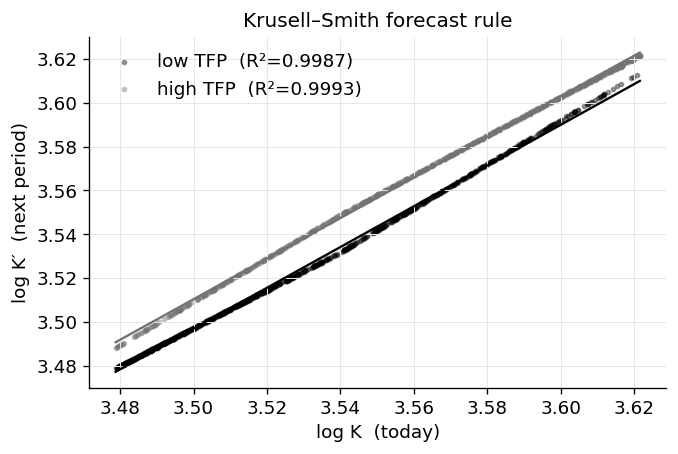

In [3]:
burn = 300
logK = np.log(ks.K_path)
x, y, zt = logK[burn:-1], logK[burn + 1:], Z_path[burn:]
cols = _nbstyle.palette(2)
fig, ax = plt.subplots()
for iZ, (c, lab) in enumerate(zip(cols, ["low TFP", "high TFP"])):
    m = zt == iZ
    ax.scatter(x[m], y[m], s=6, color=c, alpha=0.35, label=f"{lab}  (R²={ks.r_squared[iZ]:.4f})")
    xs = np.linspace(x.min(), x.max(), 50)
    ax.plot(xs, ks.b0[iZ] + ks.b1[iZ] * xs, color=c, linewidth=1.4)
ax.set_xlabel("log K  (today)"); ax.set_ylabel("log K′  (next period)")
ax.set_title("Krusell–Smith forecast rule"); ax.legend(loc="upper left")
plt.show()

### Supporting — the simulated capital path
Mean capital fluctuates around the no-aggregate-risk level K* as TFP switches;
shaded spans are low-TFP periods.

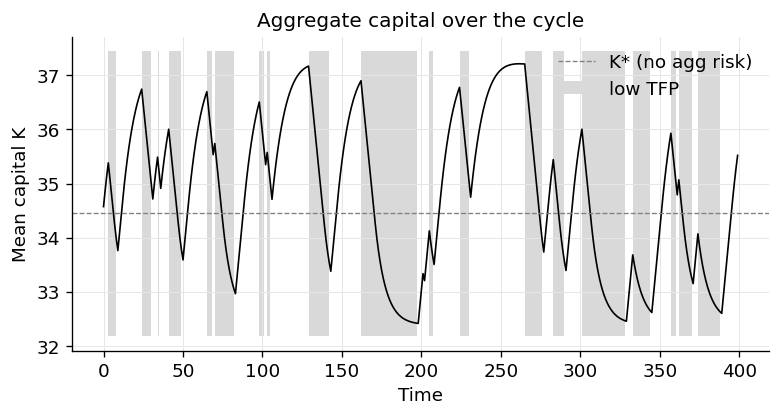

In [4]:
seg = slice(burn, burn + 400)
t = np.arange(400)
fig, ax = plt.subplots(figsize=(7.5, 3.4))
ax.plot(t, ks.K_path[seg], color="0.0", linewidth=1.0)
ax.axhline(ks.no_agg_risk_K, color="0.5", linestyle="--", linewidth=0.8, label="K* (no agg risk)")
low = Z_path[seg] == 0
ax.fill_between(t, ax.get_ylim()[0], ax.get_ylim()[1], where=low, color="0.85",
                step="mid", linewidth=0, label="low TFP")
ax.set_xlabel("Time"); ax.set_ylabel("Mean capital K")
ax.set_title("Aggregate capital over the cycle"); ax.legend(loc="upper right")
plt.show()

## 2. A perfect-foresight transition (MIT shock)
Start the Aiyagari economy capital-scarce (everyone poor) and watch it converge
back to its steady state; `r` falls and `K` rises along the path.

transition converged in 24 iters (gap 1.9e-03); K: 1.52 → 7.46  (SS 7.49)


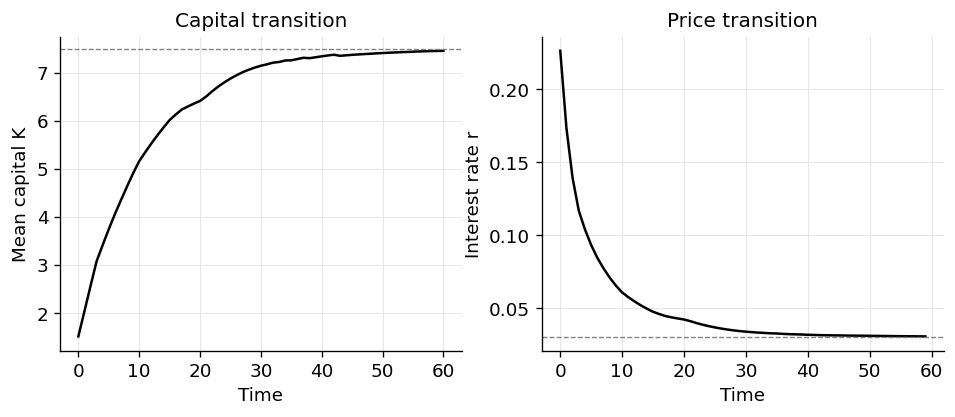

In [5]:
ai = aiyagari_steady_state(n_z=5, n_a=100, a_max=50.0, gamma=1.0)
eqp = ai["equilibrium"].problem
a_g = np.asarray(eqp.a_grid, dtype=float)
z_g = np.asarray(eqp.z_grid, dtype=float)
P_g = np.asarray(eqp.P_z, dtype=float)
L = ai["L"]; alpha, delta, beta = 0.36, 0.08, 0.96
V_ss = ai["equilibrium"].solution.V
r_ss = ai["r"]

mu0 = np.zeros_like(ai["equilibrium"].distribution)
mu0[3, :] = markov_stationary(P_g)                        # all mass at a low asset node

def _wage(r):
    KL = (alpha / (r + delta)) ** (1.0 / (1.0 - alpha))
    return (1.0 - alpha) * KL ** alpha

def build_problem(t, price_path):
    r = float(price_path[t]); w = _wage(r)
    def rf(ap, a, z, xp=np):
        c = w * xp.exp(z) + (1.0 + r) * a - ap
        return xp.where(c > 0.0, xp.log(xp.maximum(c, 1e-12)), -np.inf)
    return VFIProblem(a_grid=a_g, z_grid=z_g, P_z=P_g, return_fn=rf, beta=beta,
                      options=dict(tol=1e-9, n_howard=30))

def implied_price_path(dists, policies, price_path):
    Ks = np.array([float(np.sum(d * a_g[:, None])) for d in dists[:-1]])
    Ks = np.maximum(Ks, 1e-6)
    return alpha * (Ks / L) ** (alpha - 1.0) - delta

T = 60
tp = transition_path(mu0, V_ss, build_problem, implied_price_path,
                     np.full(T, r_ss), damping=0.2, tol=2e-3, max_iter=600)
K_tp = np.array([float(np.sum(d * a_g[:, None])) for d in tp.distributions])
print(f"transition converged in {tp.n_iter} iters (gap {tp.gap:.1e}); "
      f"K: {K_tp[0]:.2f} → {K_tp[-1]:.2f}  (SS {ai['K']:.2f})")
assert K_tp[-1] > K_tp[0]                                  # capital rebuilds toward SS

fig, (a1, a2) = plt.subplots(1, 2, figsize=(9.5, 3.4))
a1.plot(K_tp, color="0.0"); a1.axhline(ai["K"], color="0.5", linestyle="--", linewidth=0.8)
a1.set_xlabel("Time"); a1.set_ylabel("Mean capital K"); a1.set_title("Capital transition")
a2.plot(tp.price_path, color="0.0"); a2.axhline(r_ss, color="0.5", linestyle="--", linewidth=0.8)
a2.set_xlabel("Time"); a2.set_ylabel("Interest rate r"); a2.set_title("Price transition")
plt.show()

**Read the output.** We start the economy capital-scarce — all mass at a low asset node — so
capital is below its steady state and the marginal product of capital, hence $r$, is high.
As households rebuild their precautionary buffers, **$K$ rises monotonically toward the SS**
(left panel, converging on the dashed line) while **$r$ falls** (right panel): a more
capital-abundant economy earns a lower return, exactly $r=\alpha(K/L)^{\alpha-1}-\delta$
decreasing in $K$. This is the perfect-foresight counterpart to the stochastic fluctuations
above — the same price mechanics, but tracing a single anticipated path between steady states
rather than a stationary cycle.

## 3. The representative-agent benchmark
With no heterogeneity, the stochastic neoclassical growth model has an ergodic
capital distribution tightly around its analytical steady state.

rep-agent: mean K = 53.797, analytical K_ss = 53.755


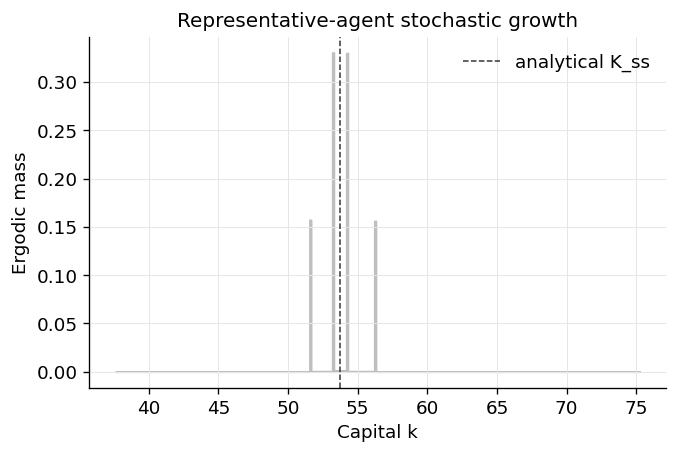

In [6]:
ng = neoclassical_growth(n_k=300)
mu_k = ng["distribution"].sum(axis=1)                      # marginal over TFP
print(f"rep-agent: mean K = {ng['mean_capital']:.3f}, analytical K_ss = {ng['K_ss']:.3f}")
assert abs(ng["mean_capital"] / ng["K_ss"] - 1.0) < 0.05
fig, ax = plt.subplots()
ax.fill_between(ng["k_grid"], mu_k, color="0.75", step="mid")
ax.axvline(ng["K_ss"], color="0.2", linestyle="--", linewidth=0.9, label="analytical K_ss")
ax.set_xlabel("Capital k"); ax.set_ylabel("Ergodic mass")
ax.set_title("Representative-agent stochastic growth"); ax.legend()
plt.show()

## Your turn — does the forecast rule actually generalize?

The R² above is *in-sample*: the rule was fit on the very path it is scored against, so a
high R² could in principle be over-fitting. The honest test is **out-of-sample**. Reusing the
already-solved `ks` (no slow re-solve), we split the post-burn-in simulation into a *fit*
segment and a *held-out* segment, re-estimate `b0[Z] + b1[Z]·logK` on the fit segment only,
and score it on the held-out segment. If approximate aggregation is real, the held-out R²
should stay near the in-sample value. Change `split` below.

In [7]:
# ← Change this train/test split fraction (fit on the first `split` of the post-burn-in path,
# score on the rest). Keep it in (0, 1); the rule should generalize at any reasonable value.
split = 0.7
x_all, y_all, z_all = logK[burn:-1], logK[burn + 1:], Z_path[burn:]   # reuse the solved ks
k = int(split * x_all.size)
r2_test = np.empty(2)
for iZ in range(2):                                       # one rule per aggregate state
    fit = z_all[:k] == iZ
    A = np.vstack([np.ones(fit.sum()), x_all[:k][fit]]).T
    coef, *_ = np.linalg.lstsq(A, y_all[:k][fit], rcond=None)
    te = z_all[k:] == iZ                                  # held-out segment, same state
    yhat = coef[0] + coef[1] * x_all[k:][te]
    yt = y_all[k:][te]
    ss_tot = float(np.sum((yt - yt.mean()) ** 2))
    r2_test[iZ] = 1.0 - float(np.sum((yt - yhat) ** 2)) / ss_tot
print(f"split={split}: out-of-sample R² per state = {np.round(r2_test, 5)}  "
      f"(in-sample {np.round(ks.r_squared, 5)})")
assert r2_test.min() > 0.9, r2_test     # the rule generalizes: held-out fit stays high

split=0.7: out-of-sample R² per state = [0.99869 0.99929]  (in-sample [0.99867 0.99929])


**Prompts.** (1) Shrink the fit window (`split = 0.4`) — the held-out R² should barely move,
because the rule has only two parameters per state and the path is long. (2) Compare
`r2_test` to the in-sample `ks.r_squared`: out-of-sample is *not* systematically worse, the
signature of genuine approximate aggregation rather than over-fitting. (3) *Stretch* (slow,
re-solves the fixed point): call `krusell_smith(n_a=150, n_K=5, T=2000, burn_in=300, seed=0,
Z_vals=(0.96, 1.04))` to widen the aggregate-TFP spread, and check that the two forecast
slopes `b1` separate while each state's R² stays ≈ 0.999.

**How comprehensive is this?** This is one corner of `puremacro.vfi`'s heterogeneous-agent
toolkit. The same `VFIProblem` → solve → distribution → market-clearing stack powers
**Aiyagari GE** (NB01), **life-cycle / OLG** with mortality (NB03), **Hopenhayn** firm
entry/exit (NB04), and **two-asset** portfolios with EGM and Epstein–Zin preferences (NB05).
`transition_path` handles deterministic MIT-shock transitions between steady states, and
`neoclassical_growth` is the representative-agent reference used above.